# THE OSCARS
## 1927-2024

### Integrantes
* Antônio Duarte
* Guilherme Ribeiro
* João Gabriel
* Josué Mykael

### Introdução
O objetivo deste projeto é investigar a diversidade e a representatividade nos Oscars ao longo da história da premiação, analisando fatores como gênero, raça e nacionalidade entre indicados e vencedores.

Além disso, o projeto busca compreender se acontecimentos sociais influenciaram mudanças na Academia do Oscar, principalmente após o movimento #OscarsSoWhite.

### Análise Inicial

In [ ]:
import pandas as pd

In [ ]:
df_oscar_incompleto = pd.read_csv("datasets/oscarwinners.csv")
df_oscar_completo = pd.read_csv("datasets/oscar2024.csv")
df_imdb = pd.read_csv("datasets/world_imdb_movies_top_movies_per_year.csv")

In [ ]:
print(list(df_imdb.columns))

In [ ]:
print("\nInformações sobre os dados IMDB:")
df_imdb.info()

In [ ]:
print("\nInformações sobre os dados Oscar (1929 até 2014):")
df_oscar_incompleto.info()

In [ ]:
print("\nInformações sobre os dados Oscar (1929 até 2024):")
df_oscar_completo.info()

### Passo 1: Filtragem
Primeiramente vamos remover de "oscar2024" a parte que falta para complementarmos os vencedores em "oscarwinners".

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("datasets/oscar2024.csv")

Aqui eu faço uma filtragem dos dados que me serão necessários para a análise:

In [ ]:
filtro_anos = df["year_film"].between(2014, 2024)
filtro_vencedores = (df["winner"] == True)

In [ ]:
categorias_principais = [ 
    "DIRECTING",
    "ACTOR IN A LEADING ROLE",
    "ACTRESS IN A LEADING ROLE",
    "ACTOR IN A SUPPORTING ROLE",
    "ACTRESS IN A SUPPORTING ROLE",
]

filtro_categorias = df["category"].isin(categorias_principais)

In [ ]:
df_resultado = df[filtro_anos & filtro_vencedores & filtro_categorias]
df_resultado.head()

e transformo tudo em um csv novo, contendo apenas os vencedores de 2014 a 2024.

In [ ]:
df_resultado.to_csv("datasets/oscar_vencedores_2014_2024.csv", index=False)

### Passo 2: Organizar
Agora vamos organizar o novo csv para deixarmos compatível com o "oscarwinners" e uni-los.

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df_24 = pd.read_csv('datasets/oscar_vencedores_2014_2024.csv')

Vamos padronizar as categorias para facilitar o merge

In [ ]:
mapa_categorias = {
    'ACTOR IN A LEADING ROLE': 'Best Actor',
    'ACTOR IN A SUPPORTING ROLE': 'Best Supporting Actor',
    'ACTRESS IN A LEADING ROLE': 'Best Actress',
    'ACTRESS IN A SUPPORTING ROLE': 'Best Supporting Actress',
    'DIRECTING': 'Best Director'
}

df_24['category'] = df_24['category'].replace(mapa_categorias)
print(df_24['category'].head())

In [ ]:
df_24 = df_24.rename(columns={
    'film': 'movie',
    'year_ceremony': 'year_edition'
})

In [ ]:
colunas = [
    'name', 
    'birth_year', 
    'birth_date', 
    'birthplace', 
    'race_ethnicity', 
    'religion', 
    'sexual_orientation', 
    'year_edition', 
    'category', 
    'movie' ]

df_24_padronizado = df_24.reindex(columns=colunas)

In [ ]:
df_24_padronizado.to_csv("datasets/oscar_vencedores_2014_2024_organizado.csv", index=False)

### Passo 3: União
Agora vamos unir o "oscar_vencedores_2014_2024_organizado" a "oscarwinners"

In [ ]:
import pandas as pd

In [ ]:
df_antigo = pd.read_csv('datasets/oscarwinners.csv')
df_novo = pd.read_csv('datasets/oscar_vencedores_2014_2024_organizado.csv')

Uso o concat para uni-los

In [ ]:
df_oscar_completo = pd.concat([df_antigo, df_novo], ignore_index=True)
print(df_oscar_completo.tail())

In [ ]:
df_oscar_completo.to_csv('datasets/oscartotal.csv', index=False, encoding='utf-8')

Bom, nosso csv novo abrange de 1929 (primeira cerimônia do oscar) ate 2024, mas, para deixar mais completo, manualmente adicionei os vencedores de 2025 e 2026 também.

Agora vamos unir nosso novo csv de vencedores do oscar, que contém todos os vencedores de 1929 até 2026, com nosso dataset do imdb, para unir as informações gerais dos filmes em que os vencedores participaram.

In [ ]:
df_oscar = pd.read_csv('datasets/oscartotal.csv')
df_imdb = pd.read_csv('datasets/world_imdb_movies_top_movies_per_year.csv')

Aqui fazemos uma padronização para que o link com o nome do título seja feita corretamente, deixando todas as letras minusculas e tirando duplicatas pro título não aparecer 2 vezes

In [ ]:
df_oscar['movie_clean'] = df_oscar['movie'].astype(str).str.strip().str.lower()
df_imdb['title_clean'] = df_imdb['title'].astype(str).str.strip().str.lower()

df_imdb_unique = df_imdb.drop_duplicates(subset=['title_clean'], keep='first')

In [ ]:
df_merged = pd.merge(
    df_oscar, 
    df_imdb_unique, 
    left_on='movie_clean', 
    right_on='title_clean', 
    how='left'
)

df_merged.tail()

In [ ]:
df_merged.to_csv('datasets/oscar_imdb_merged.csv', index=False)

Por fim fazemos a alteração manual de Hispanic, Middle Eastern e Multiracial com base em afirmações própria dos atores 1 a 1 para reduzir a 3 etnias, visto que são poucas a fazer a alteração.

In [ ]:
df_oscar = pd.read_csv('datasets/oscar_imdb_merged.csv')
df_oscar['race_ethnicity'].value_counts(dropna=False)

Checagem pra ver quem são:

In [ ]:
hispanic = df_oscar[df_oscar['race_ethnicity'].str.strip().str.lower() == 'hispanic']
print(hispanic)

In [ ]:
multi = df_oscar[df_oscar['race_ethnicity'].str.strip().str.lower() == 'multiracial']
print(multi)

In [ ]:
middle = df_oscar[df_oscar['race_ethnicity'].str.strip().str.lower() == 'middle eastern']
print(middle)

Antes do age_at_win, adicionei manualmente o ano de aniversário dos vencedores de 2014 a 2026 que não constavam no csv original "oscar2024".

In [ ]:
df_oscar['sexual_orientation'] = df_oscar['sexual_orientation'].fillna('Unknown')
df_oscar['religion'] = df_oscar['religion'].fillna('Unknown')
df_oscar['age_at_win'] = df_oscar['year_edition'] - df_oscar['birth_year']

In [ ]:
df_oscar['age_at_win'].head()

In [ ]:
df_oscar.to_csv('datasets/oscar_imdb_merged.csv', index=False, encoding='utf-8')

### Passo 4: Análise
Agora, com todas as informaçôes reunidas, vamos começar a análise fazendo uma organização no csv final nas categorias que vamos investigar.

In [1]:
import pandas as pd

In [8]:
df_oscar = pd.read_csv('datasets/oscar_imdb_merged.csv')
df_oscar['sexual_orientation'].value_counts(dropna=False)

sexual_orientation
Straight             433
Bisexual              21
Na                    10
Gay                    7
Matter of Dispute      3
Lesbian                2
Name: count, dtype: int64

In [9]:
df_oscar['race_ethnicity'].value_counts(dropna=False)

race_ethnicity
White    442
Black     24
Asian     10
Name: count, dtype: int64

In [4]:
df_oscar.shape

(476, 36)

Agora vamos para a análise gráfica:

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Para fazer a análise de década, garanto que "year_edition" é numérico e faço a transformação p década, ex: 2023, divido inteiramente por 10 = 202, multiplico por 10 = 2020, e a validação evita erros.

In [11]:
df = pd.read_csv('datasets/oscar_imdb_merged.csv')

df['year_edition'] = pd.to_numeric(df['year_edition'], errors='coerce').fillna(0).astype(int)

df['decade'] = (df['year_edition'] // 10) * 10
df_valid = df[df['decade'] >= 1920].copy()

Proporção racial dos vencedores por década

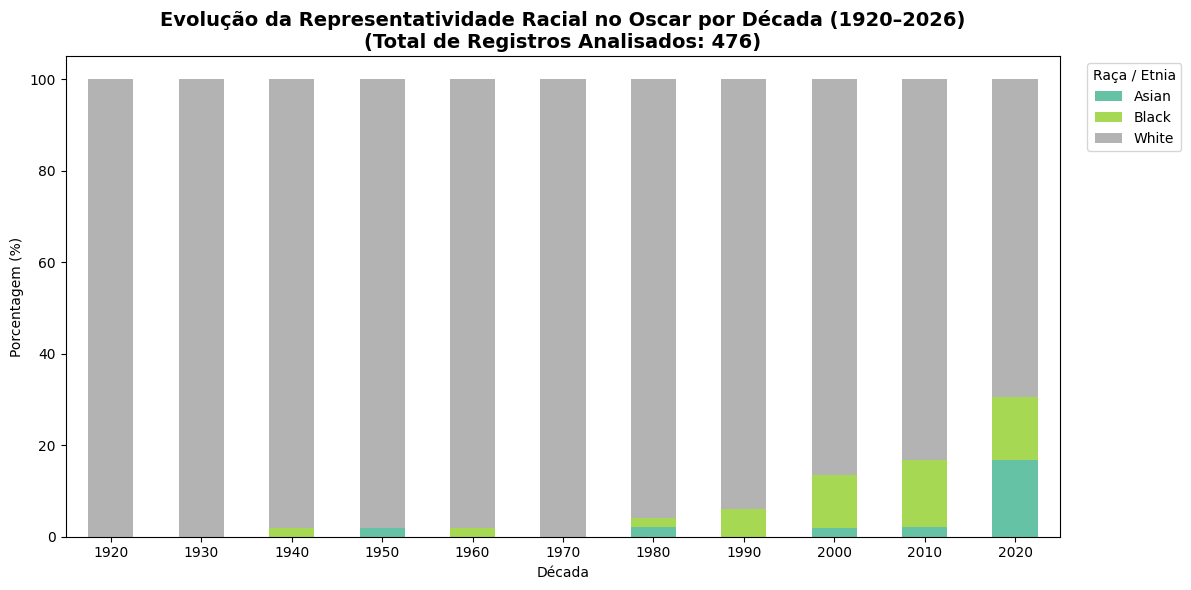

In [12]:
total = len(df_valid)

crosstab_race = pd.crosstab(df_valid['decade'], df_valid['race_ethnicity'], normalize='index') * 100

ax = crosstab_race.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='Set2')
plt.title(f'Evolução da Representatividade Racial no Oscar por Década (1920–2026)\n(Total de Registros Analisados: {total})', fontsize=14, fontweight='bold')
plt.xlabel('Década')
plt.ylabel('Porcentagem (%)')
plt.legend(title='Raça / Etnia', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Distribuição da representatividade por categoria de premiação

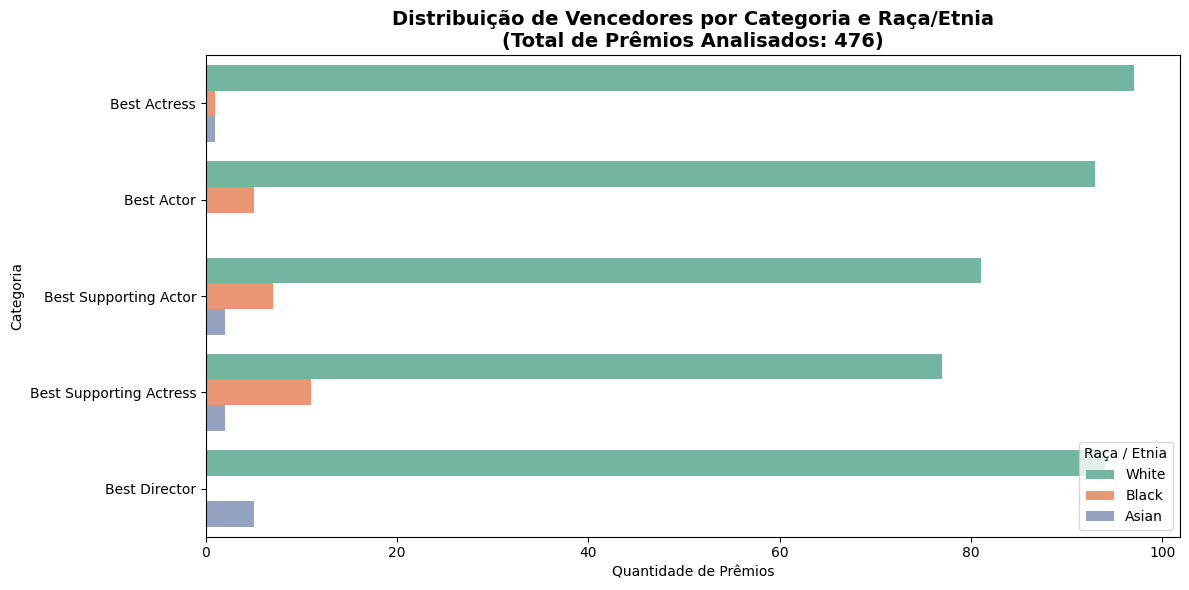

In [13]:
plt.figure(figsize=(12, 6))

sns.countplot(data=df, y='category', hue='race_ethnicity', palette='Set2')
plt.title(f'Distribuição de Vencedores por Categoria e Raça/Etnia\n(Total de Prêmios Analisados: {total})', fontsize=14, fontweight='bold')
plt.xlabel('Quantidade de Prêmios')
plt.ylabel('Categoria')
plt.legend(title='Raça / Etnia', loc='lower right')
plt.tight_layout()
plt.show()

Comparar a idade média em que homens e mulheres vencem o Oscar nas categorias de atuação.

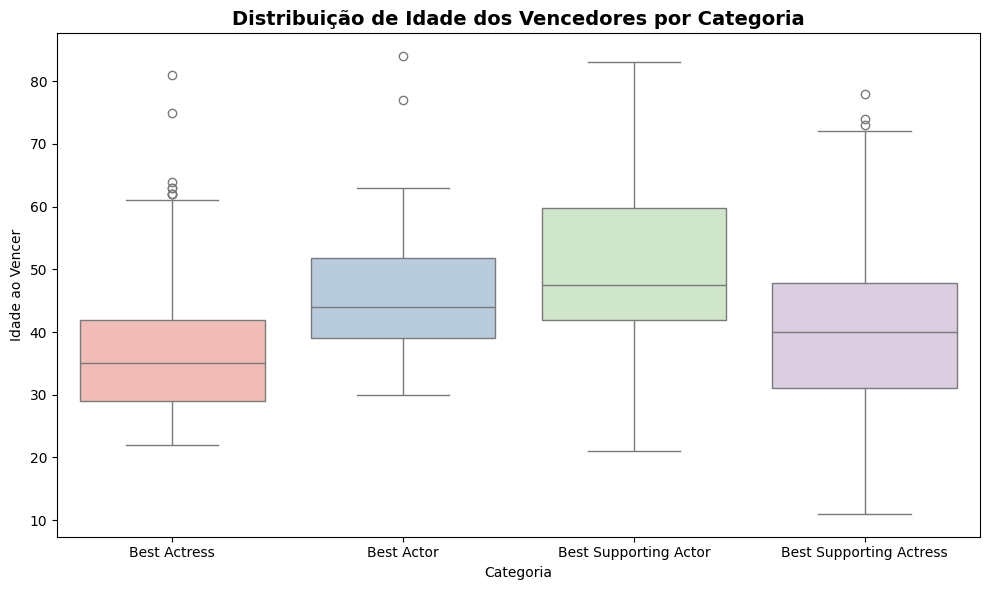

In [14]:
plt.figure(figsize=(10, 6))
categorias_atuacao = ['Best Actor', 'Best Actress', 'Best Supporting Actor', 'Best Supporting Actress']
df_atuacao = df_valid[df_valid['category'].isin(categorias_atuacao)].copy()

sns.boxplot(data=df_atuacao, x='category', y='age_at_win', hue='category', palette='Pastel1', legend=False)

plt.title('Distribuição de Idade dos Vencedores por Categoria', fontsize=14, fontweight='bold')
plt.xlabel('Categoria')
plt.ylabel('Idade ao Vencer')
plt.tight_layout()
plt.show()

Utilizando um gráfico de dispersão ao longo dos anos, podemos visualizar se o reconhecimento de artistas abertamente LGBTQIA+ é uma conquista recente ou se possui histórico nas primeiras edições do Oscar. Esse cruzamento nos permite entender não só a presença, mas a evolução temporal dessa representatividade.

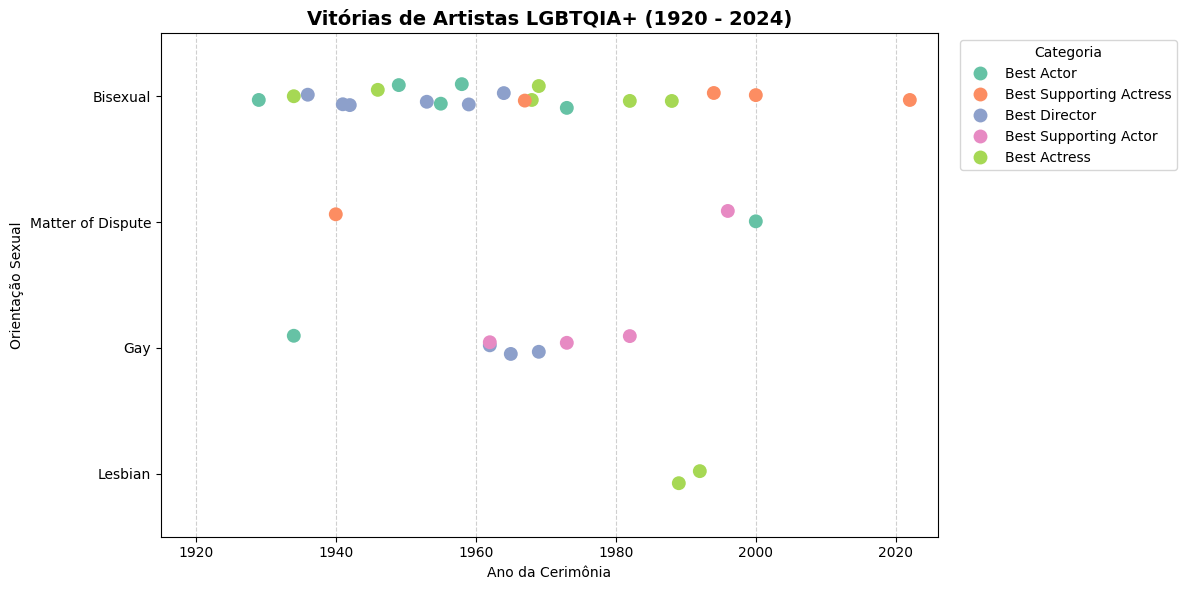

In [15]:
df_lgbt = df_valid[~df_valid['sexual_orientation'].str.strip().str.capitalize().isin(['Unknown', 'Straight', 'Na', 'Nan'])]

plt.figure(figsize=(12, 6))

sns.stripplot(
    data=df_lgbt, 
    x='year_edition', 
    y='sexual_orientation', 
    hue='category', 
    palette='Set2', 
    size=10,
    jitter=True 
)

plt.title('Vitórias de Artistas LGBTQIA+ (1920 - 2024)', fontsize=14, fontweight='bold')
plt.xlabel('Ano da Cerimônia')
plt.ylabel('Orientação Sexual')
plt.xlim(1915, 2026) 

plt.legend(title='Categoria', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Para analisar se a inclusão gera retorno financeiro, calculamos o lucro limpo (Lucro bruto - Orçamento) de cada filme. Utilizaremos a mediana para evitar distorções e ter uma visão realista de qual grupo tende a lucrar mais de forma consistente

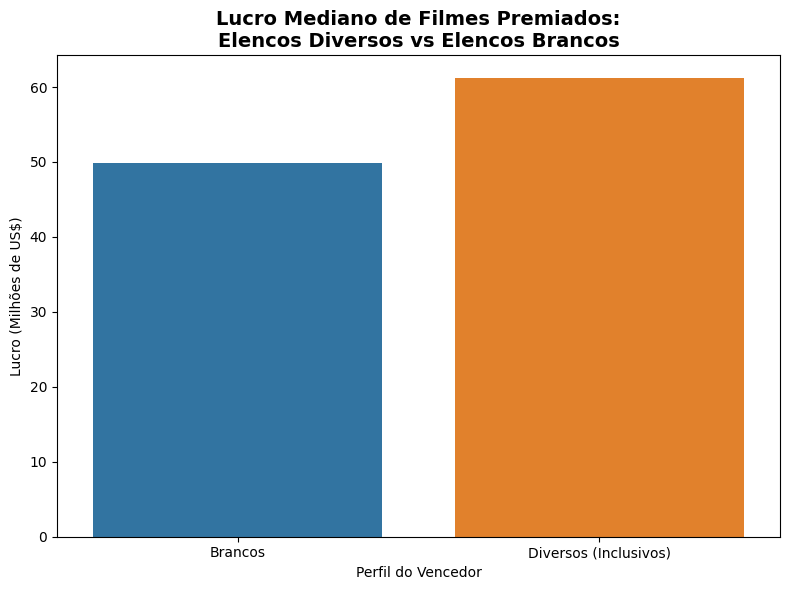

In [16]:
df_valid['perfil_racial'] = df_valid['race_ethnicity'].apply(
    lambda x: 'Brancos' if str(x).strip().lower() == 'white' else 'Diversos (Inclusivos)'
)
df_valid['orcamento'] = pd.to_numeric(df_valid['budget'].astype(str).str.replace(r'[^\d.]', '', regex=True), errors='coerce')
df_valid['bilheteria'] = pd.to_numeric(df_valid['gross_world_wide'].astype(str).str.replace(r'[^\d.]', '', regex=True), errors='coerce')

df_valid['lucro_milhoes'] = (df_valid['bilheteria'] - df_valid['orcamento']) / 1_000_000

df_financeiro = df_valid.dropna(subset=['lucro_milhoes'])

plt.figure(figsize=(8, 6))

sns.barplot(
    data=df_financeiro, 
    x='perfil_racial', 
    y='lucro_milhoes', 
    hue='perfil_racial',
    estimator=np.median,            
    legend=False,
    errorbar=None
)

plt.title('Lucro Mediano de Filmes Premiados:\nElencos Diversos vs Elencos Brancos', fontsize=14, fontweight='bold')
plt.xlabel('Perfil do Vencedor')
plt.ylabel('Lucro (Milhões de US$)')
plt.tight_layout()
plt.show()

### Conclusão

De acordo com nossas análises, verificamos que a quantidade de pessoas brancas vencedoras do Oscar ainda é significativamente maior do que a de pessoas pertencentes a outros grupos étnicos. Entretanto, observa-se que, a partir da década de 1980, essa diferença vem diminuindo gradualmente, indicando um aumento da diversidade étnico-racial entre os vencedores ao longo das últimas décadas.

Nas categorias individuais de atuação, como Melhor Ator e Melhor Atriz, os vencedores brancos ainda representam a maioria dos premiados. Entretanto, categorias como Melhor Ator Coadjuvante e Melhor Atriz Coadjuvante apresentam uma maior presença de vencedores negros e hispânicos, embora os atores brancos ainda sejam maioria nesses grupos de premiação.

Percebemos também que as mulheres tendem a conquistar o prêmio em idades mais jovens do que os homens. Entretanto, os homens apresentam uma maior longevidade no reconhecimento pela Academia, permanecendo elegíveis ou sendo premiados ao longo de um período mais extenso de suas carreiras.

Também foi verificado a presença de artistas LGBTQIA+ entre os vencedores do Oscar desde as primeiras décadas da premiação. Embora existam registros de reconhecimento desde o início da história da cerimônia, observa-se uma maior concentração dessas vitórias nas décadas mais recentes. Esse cenário pode estar relacionado ao aumento da visibilidade e da representatividade LGBTQIA+ na indústria cinematográfica ao longo do tempo.

Por fim, analisamos se a inclusão e a diversidade racial estão associadas ao retorno financeiro dos filmes premiados. Para isso, calculamos o lucro líquido de cada produção, obtido pela diferença entre a bilheteria mundial e o orçamento do filme, e utilizamos a mediana como medida de tendência central, buscando reduzir a influência de valores extremos. Os resultados indicam que os filmes associados a vencedores de grupos racialmente diversos apresentaram um lucro mediano superior ao daqueles associados a vencedores brancos, com aproximadamente US$ 83 milhões contra US$ 50 milhões, respectivamente. Esse resultado sugere que a diversidade não está necessariamente associada a um menor desempenho financeiro e pode coexistir com resultados comerciais positivos.

Após a análise de todo o material, concluímos que os resultados apontam para uma evolução gradual da representatividade no Oscar, embora ainda existam desigualdades que demonstram que a busca por uma maior diversidade e inclusão na indústria cinematográfica permanece relevante.
